# K-means on synthetic data
## Step 1 - generating a synthetic dataset

## Synthetic data

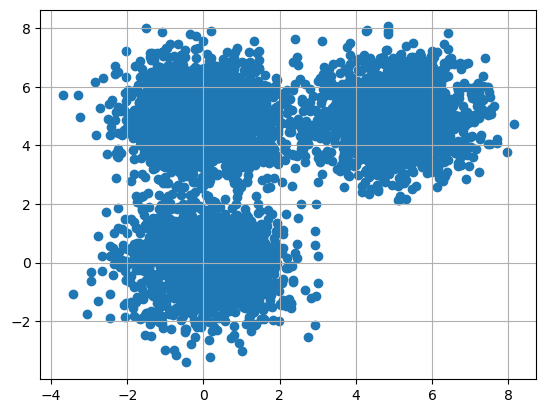

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


n = 5000

# cluster sizes
n1 = n2 = n3 = n // 3

# define means manually
mean1 = [0, 0]
mean2 = [5, 5]
mean3 = [0, 5]

# generate clusters
c1 = np.random.randn(n1, 2) + mean1
c2 = np.random.randn(n2, 2) + mean2
c3 = np.random.randn(n3, 2) + mean3

X_synth = np.vstack((c1, c2, c3))

plt.scatter(X_synth[:, 0], X_synth[:, 1])
plt.grid(True)
plt.show()

## Real world data - MNIST dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version = 1, as_frame=False)

X = mnist.data.astype(np.float64)
X = X / 255.0 #normalizing the data
y = mnist.target.astype(int)

#subsetting mnist to work with a more manageable size

subset_size = 5000
indices = np.random.choice(X.shape[0], subset_size, replace=False)

X_subset = X[indices]
y_subset = y[indices]
X = X_subset
y = y_subset

print(X.shape)
print(y.shape)

(5000, 784)
(5000,)


## kmeans function

In [3]:
# helper functions

def get_labels(X, centroids):
    distances = []

    for centroid in centroids:
        dist = np.sum((X - centroid) ** 2, axis=1)
        distances.append(dist)
    distances = np.array(distances).T

    return np.argmin(distances, axis=1)

def new_centroids(X, labels, k):
    n_features = X.shape[1]
    centroids = np.zeros((k, n_features))

    for i in range(k):
        cluster_points = X[labels == i]
        if len(cluster_points) == 0:
            centroids[i] = X[np.random.randint(X.shape[0])]
        else:
            centroids[i] = cluster_points.mean(axis=0)

    return centroids


In [4]:
# centroid initialization functions

# base kmeans:

def random_centroids(X, k):
    
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

# kmeans++:

def plus_plus_centroids(X, k):
    n = X.shape[0]

    centroids = []
    chosen_indices = set()

    first_idx = np.random.randint(n)
    centroids.append(X[first_idx])
    chosen_indices.add(first_idx)

    for _ in range(k - 1):
        dist_sq = np.min(
            np.sum(
                (X[:, np.newaxis] - np.array(centroids)) ** 2,
                axis=2
            ),
            axis=1
        )
        probs = dist_sq / dist_sq.sum()

        # avoiding duplicates
        while True:
            next_idx = np.random.choice(n, p=probs)

            if next_idx not in chosen_indices:
                chosen_indices.add(next_idx)
                break

        centroids.append(X[next_idx])

    return np.array(centroids)

In [5]:
#kmeans final function

def kmeans(X, k, init = "random"):

    if(init == "random"):
        centroids = random_centroids(X,k)
    elif(init == "++"):
        centroids = plus_plus_centroids(X, k)

    for iteration in range(100):

        old_centroids = centroids.copy()
        labels = get_labels(X, centroids)
        centroids = new_centroids(X, labels, k)

        if np.allclose(centroids, old_centroids):
            break

    return labels, centroids

## Example of kmeans results

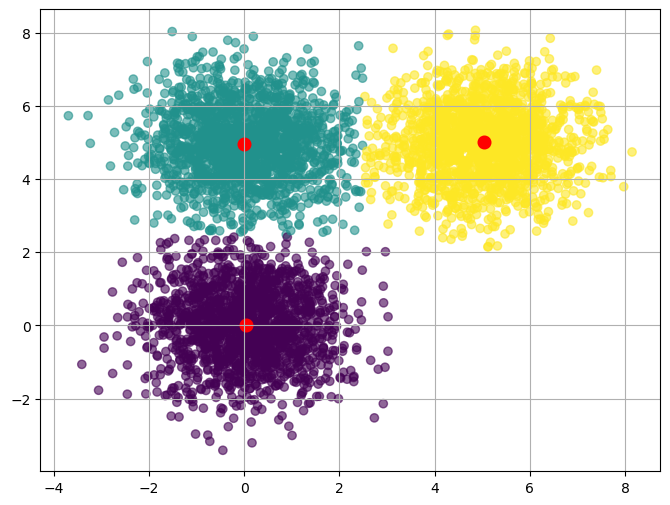

In [6]:
#Synthetic data example - visualizing full clusters with centroids

labels_synth, centroids_synth = kmeans(X_synth, 3)

plt.figure(figsize=(8, 6))

# plot data points
plt.scatter(
    X_synth[:, 0],
    X_synth[:, 1],
    c=labels_synth,
    alpha=0.6
)

# plot centroids
plt.scatter(
    centroids_synth[:, 0],
    centroids_synth[:, 1],
    color='red',
    marker='.',
    s=200,
    linewidths=3
)

plt.grid(True)
plt.show()

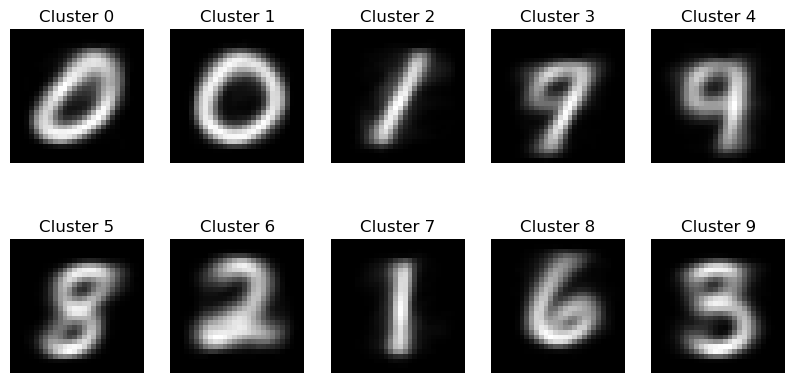

In [7]:
#Real data exaple - visualizing the selected centroids for each cluster

labels, centroids = kmeans(X, 10)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(centroids[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Cluster {i}")
    ax.axis('off')

plt.show()

## Calculating inertia

In [8]:
def compute_inertia(X, labels, centroids):
    inertia = 0
    
    for i in range(len(X)):
        centroid = centroids[labels[i]]
        inertia += np.sum((X[i] - centroid) ** 2)
    
    return inertia

## Running repearted trials to calculate variance in results

In [9]:
def kmeans_trials(X, k, n_trials):
    inertias = []
    
    for i in range(n_trials):
        labels, centroids = kmeans(X,k)
        inertia = compute_inertia(X, labels, centroids)
        inertias.append(inertia)

    return inertias 

def kmeans_plus_plus_trials(X, k, n_trials):
    inertias = []
    
    for i in range(n_trials):
        labels, centroids = kmeans(X,k, "++")
        inertia = compute_inertia(X, labels, centroids)
        inertias.append(inertia)

    return inertias 

## Running multiple trials

In [10]:
# running multiple (100) trials on synthetic data
# base kmeans

inertias_synth = kmeans_trials(X_synth, 3, 100)
inertias_synth_plus_plus = kmeans_plus_plus_trials(X_synth, 3, 100)

print(np.mean(inertias_synth))
print(np.mean(inertias_synth_plus_plus))

9924.35587036545
9924.35587036545


In [11]:
# running multiple (50) trails on real data

inertias_real = kmeans_trials(X, 10, 50)
inertias_real_plus_plus = kmeans_plus_plus_trials(X, 10, 50)

print(np.mean(inertias_real))
print(np.mean(inertias_real_plus_plus))

195905.68019051978
196115.1411275426


In [12]:
print("KMEANS")
print("mean:", np.mean(inertias_real))
print("best:", np.min(inertias_real))
print("std:", np.std(inertias_real))

print()

print("KMEANS++")
print("mean:", np.mean(inertias_real_plus_plus))
print("best:", np.min(inertias_real_plus_plus))
print("std:", np.std(inertias_real_plus_plus))

KMEANS
mean: 195905.68019051978
best: 195075.15028537717
std: 805.236281589373

KMEANS++
mean: 196115.1411275426
best: 195076.0915510468
std: 764.3766066617501


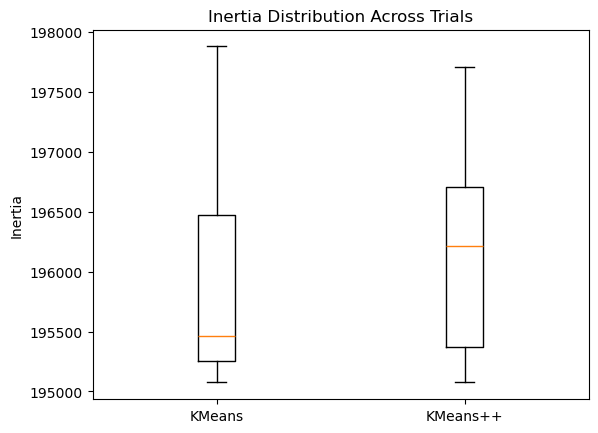

In [13]:
plt.boxplot([inertias_real, inertias_real_plus_plus],
            tick_labels=["KMeans", "KMeans++"])

plt.ylabel("Inertia")
plt.title("Inertia Distribution Across Trials")
plt.show()

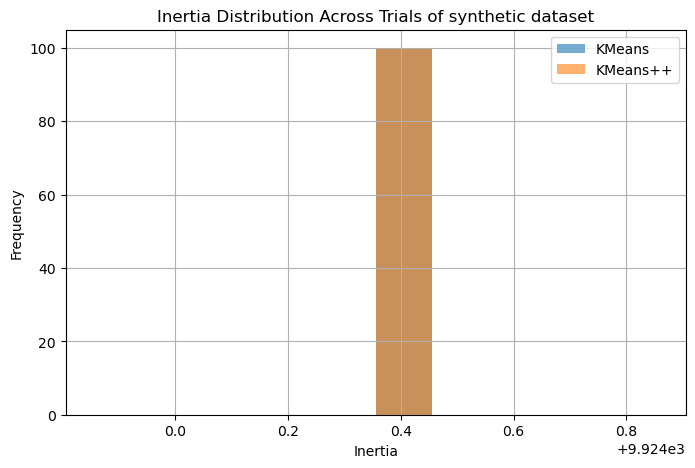

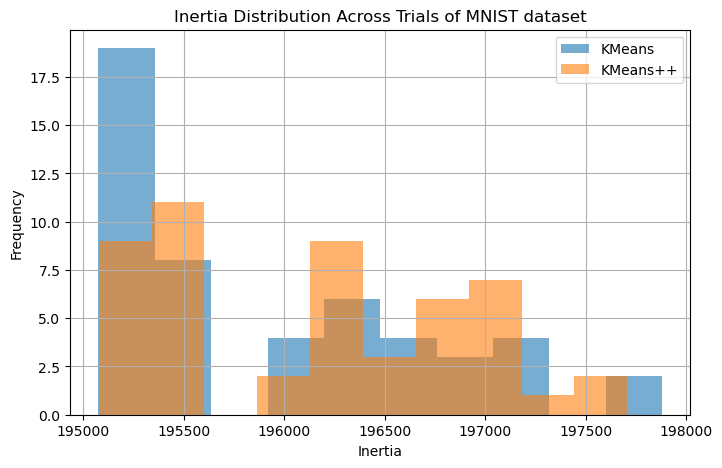

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(inertias_synth,
         bins=10,
         alpha=0.6,
         label="KMeans")

plt.hist(inertias_synth_plus_plus,
         bins=10,
         alpha=0.6,
         label="KMeans++")

plt.xlabel("Inertia")
plt.ylabel("Frequency")
plt.title("Inertia Distribution Across Trials of synthetic dataset")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8, 5))

plt.hist(inertias_real,
         bins=10,
         alpha=0.6,
         label="KMeans")

plt.hist(inertias_real_plus_plus,
         bins=10,
         alpha=0.6,
         label="KMeans++")

plt.xlabel("Inertia")
plt.ylabel("Frequency")
plt.title("Inertia Distribution Across Trials of MNIST dataset")
plt.legend()
plt.grid(True)

plt.show()